In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X = dataset.iloc[:, 3:5]
#3:5 artinya adalah mengambil kolom index 3 sampai 4 (atau 5-1)
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [5]:
X.shape

(200, 2)

In [6]:
X.isnull().sum()

,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [8]:
from sklearn.cluster import KMeans
wcss = []

for i in range (1, 15):
  kmeans = KMeans(n_clusters=i, random_state=12)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

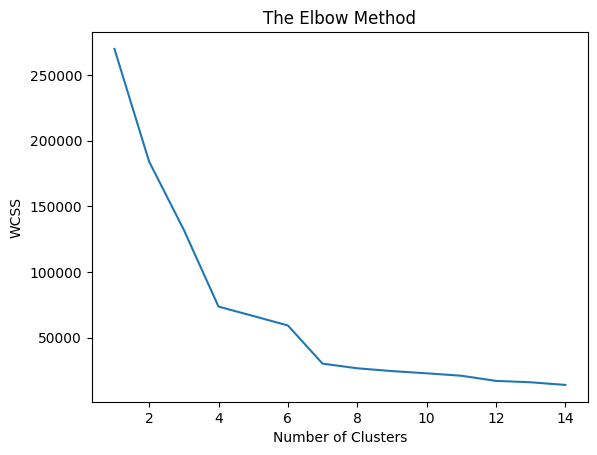

In [9]:
# Visualisasi Plot

plt.plot(range(1, 15), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=5, random_state=12)
kmeans.fit(X)

KMeans(n_clusters=5, random_state=12)

In [11]:
kmeans.labels_

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3], dtype=int32)

In [12]:
hasil_kmeans = X.copy()
hasil_kmeans["cluster"] = kmeans.labels_
hasil_kmeans.head()

,Annual Income (k$),Spending Score (1-100),cluster
0,15,39,0
1,15,81,1
2,16,6,0
3,16,77,1
4,17,40,0


Text(0, 0.5, 'Frekuensi')

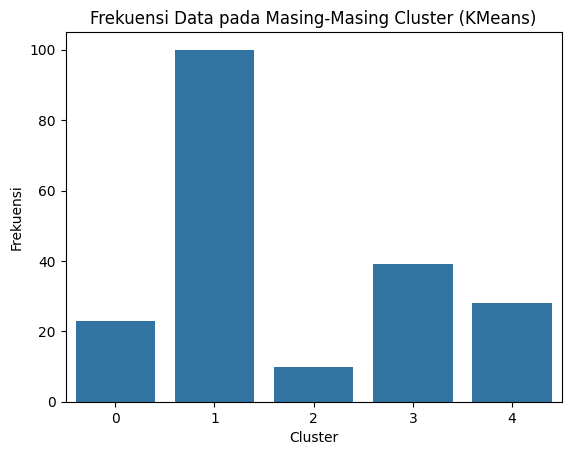

In [13]:
# Nilai untuk sumbu X dan Y
cluster_x = hasil_kmeans["cluster"].value_counts().index
cluster_y = hasil_kmeans["cluster"].value_counts().values
# Visualisasi
sns.barplot(x=cluster_x, y=cluster_y)
plt.title("Frekuensi Data pada Masing-Masing Cluster (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Frekuensi")

In [14]:
# Nilai fitur/variabel dari masing-masing cluster
ann_kmeans0 = hasil_kmeans[hasil_kmeans["cluster"] == 0].iloc[:, 0]
spend_kmeans0 = hasil_kmeans[hasil_kmeans["cluster"] == 0].iloc[:, 1]
ann_kmeans1 = hasil_kmeans[hasil_kmeans["cluster"] == 1].iloc[:, 0]
spend_kmeans1 = hasil_kmeans[hasil_kmeans["cluster"] == 1].iloc[:, 1]
ann_kmeans2 = hasil_kmeans[hasil_kmeans["cluster"] == 2].iloc[:, 0]
spend_kmeans2 = hasil_kmeans[hasil_kmeans["cluster"] == 2].iloc[:, 1]
ann_kmeans3 = hasil_kmeans[hasil_kmeans["cluster"] == 3].iloc[:, 0]
spend_kmeans3 = hasil_kmeans[hasil_kmeans["cluster"] == 3].iloc[:, 1]
ann_kmeans4 = hasil_kmeans[hasil_kmeans["cluster"] == 4].iloc[:, 0]
spend_kmeans4 = hasil_kmeans[hasil_kmeans["cluster"] == 4].iloc[:, 1]
# Pusat dari cluster (centroid)
centroid_cluster = kmeans.cluster_centers_
centroid_cluster

array([[ 26.30434783,  20.91304348],
       [ 48.26      ,  56.48      ],
       [109.7       ,  22.        ],
       [ 86.53846154,  82.12820513],
       [ 78.89285714,  17.42857143]])

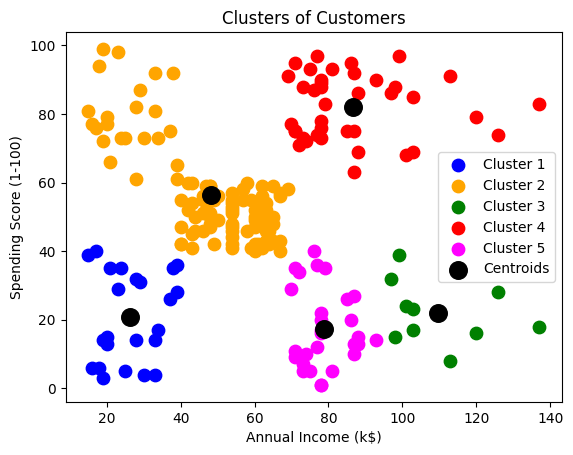

In [15]:
# VISUALISASI HASIL CLUSTERING
plt.scatter(ann_kmeans0, spend_kmeans0, s = 80, c = "blue", label = "Cluster 1")
plt.scatter(ann_kmeans1, spend_kmeans1, s = 80, c = "orange", label = "Cluster 2")
plt.scatter(ann_kmeans2, spend_kmeans2, s = 80, c = "green", label = "Cluster 3")
plt.scatter(ann_kmeans3, spend_kmeans3, s = 80, c = "red", label = "Cluster 4")
plt.scatter(ann_kmeans4, spend_kmeans4, s = 80, c = "magenta", label = "Cluster 5")
# Centroid
plt.scatter(centroid_cluster[:, 0], centroid_cluster[:, 1], s = 160, c = "black", label = "Centroids")
plt.title("Clusters of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [16]:
# Memasukkan kembali "Customer ID"-nya
hasil_kmeans["CustomerID"] = dataset["CustomerID"]
hasil_kmeans.head()

,Annual Income (k$),Spending Score (1-100),cluster,CustomerID
0,15,39,0,1
1,15,81,1,2
2,16,6,0,3
3,16,77,1,4
4,17,40,0,5


In [17]:
# Menyimpan hasil clustering
hasil_kmeans.to_csv("Hasil Clustering Menggunakan K-Means.csv", index = False)